### seting up test data preparation

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from ultralytics import YOLO

In [ ]:
!unzip -q banana_dataset.zip -d dataset/

In [ ]:
# 1. Defining Working Directory
base_dir = '/content/dataset'
test_dir = os.path.join(base_dir, 'test')

# 2. Setting Up Image Parameters
IMG_HEIGHT = 416
IMG_WIDTH = 416
BATCH_SIZE = 32

# 3. Loading Test Data
print("Loading Test Data...")
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Extracting class names and true labels
class_names = list(test_data.class_indices.keys())
y_true = test_data.classes

Loading Test Data...
Found 562 images belonging to 4 classes.


### Loading all trained models

In [ ]:
# Loading Keras Models
try:
    model_cnn = load_model('custom_cnn_model.keras')
    print("🧲 Custom CNN loaded.")
except: print("✂️ Custom CNN not found.")

try:
    model_mb = load_model('mobilenetv2_model.keras')
    print("🧲 MobileNetV2 loaded.")
except: print("✂️ MobileNetV2 not found.")

try:
    model_eff = load_model('efficientnetb0_model.keras')
    print("🧲 EfficientNetB0 loaded.")
except: print("✂️ EfficientNetB0 not found.")

try:
    model_yolo_cls = YOLO('yolo_cls_best.pt')
    print("🧲 YOLOv8 Classification loaded.")
except: print("✂️ YOLOv8 Classification not found.")

🧲 Custom CNN loaded.
🧲 MobileNetV2 loaded.
🧲 EfficientNetB0 loaded.
🧲 YOLOv8 Classification loaded.


### EVALUATION HELPER FUNCTION

In [ ]:
# To keep our code clean, we define a function to evaluate any Keras model
def evaluate_keras_model(model, model_name):
    print(f"\n{'-'*50}\nEvaluating {model_name}...\n{'-'*50}")

    # 1. Measuring Inference Time
    start_time = time.time()
    predictions = model.predict(test_data, verbose=0)
    end_time = time.time()

    inference_time = end_time - start_time
    time_per_image = (inference_time / test_data.samples) * 1000 # in milliseconds

    # 2. Getting Predicted Classes
    y_pred = np.argmax(predictions, axis=1)

    # 3. Printing Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 4. Plotting Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Setting up a filename
    safe_name = model_name.replace(" ", "_")
    image_filename = f"{safe_name}_confusion_matrix.png"

    # setting output image quality
    plt.savefig(image_filename, dpi=900, bbox_inches='tight', format='png')
    print(f"📸 Saved high-res image: {image_filename}")

    # Display Chart
    plt.show()

    # Returning metrics for final comparison table
    accuracy = accuracy_score(y_true, y_pred)
    return accuracy, time_per_image

### Evaluating Keras Models


--------------------------------------------------
Evaluating Custom CNN...
--------------------------------------------------
              precision    recall  f1-score   support

    overripe       0.93      0.75      0.83       113
        ripe       0.82      0.92      0.87       154
      rotten       0.84      0.89      0.86       185
      unripe       0.97      0.90      0.93       110

    accuracy                           0.87       562
   macro avg       0.89      0.86      0.87       562
weighted avg       0.88      0.87      0.87       562

📸 Saved high-res image: Custom_CNN_confusion_matrix.png


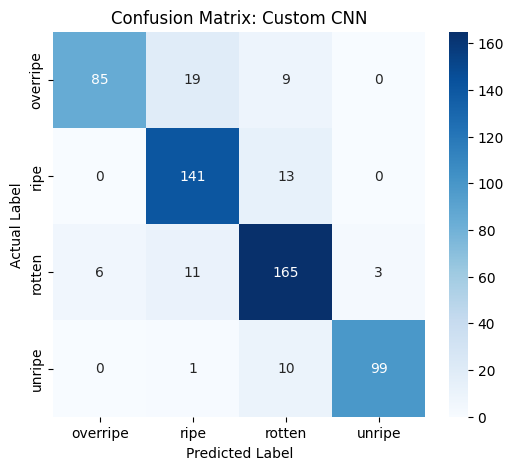


--------------------------------------------------
Evaluating MobileNetV2...
--------------------------------------------------
              precision    recall  f1-score   support

    overripe       0.96      0.96      0.96       113
        ripe       0.96      0.99      0.97       154
      rotten       0.98      0.94      0.96       185
      unripe       0.95      0.96      0.96       110

    accuracy                           0.96       562
   macro avg       0.96      0.96      0.96       562
weighted avg       0.96      0.96      0.96       562

📸 Saved high-res image: MobileNetV2_confusion_matrix.png


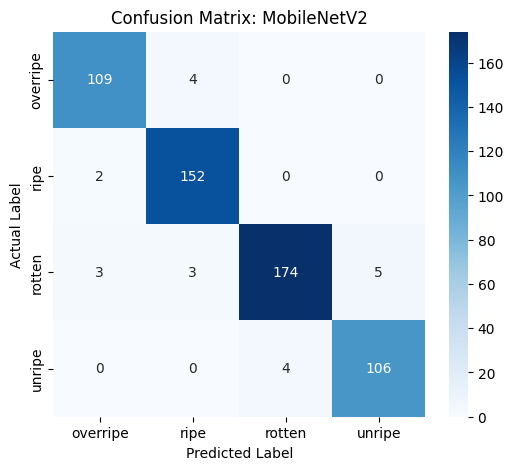


--------------------------------------------------
Evaluating EfficientNetB0...
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    overripe       0.00      0.00      0.00       113
        ripe       0.00      0.00      0.00       154
      rotten       0.33      1.00      0.50       185
      unripe       0.00      0.00      0.00       110

    accuracy                           0.33       562
   macro avg       0.08      0.25      0.12       562
weighted avg       0.11      0.33      0.16       562

📸 Saved high-res image: EfficientNetB0_confusion_matrix.png


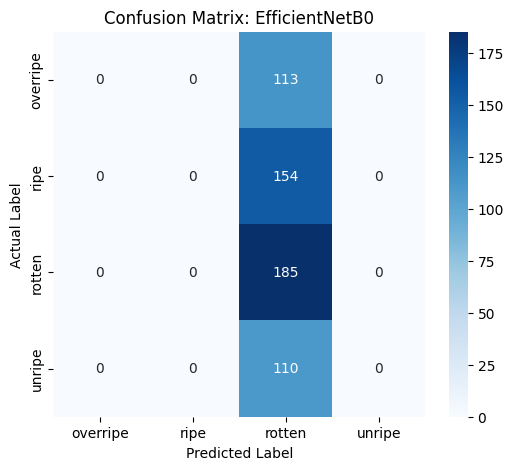

In [ ]:
results_dict = {}

if 'model_cnn' in locals():
    acc_cnn, time_cnn = evaluate_keras_model(model_cnn, "Custom CNN")
    results_dict["Custom CNN"] = {"Accuracy": acc_cnn, "Time/Image (ms)": time_cnn}

if 'model_mb' in locals():
    acc_mb, time_mb = evaluate_keras_model(model_mb, "MobileNetV2")
    results_dict["MobileNetV2"] = {"Accuracy": acc_mb, "Time/Image (ms)": time_mb}

if 'model_eff' in locals():
    acc_eff, time_eff = evaluate_keras_model(model_eff, "EfficientNetB0")
    results_dict["EfficientNetB0"] = {"Accuracy": acc_eff, "Time/Image (ms)": time_eff}

### Evaluating YOLOv8 Classification

In [ ]:
if 'model_yolo_cls' in locals():
    print(f"\n{'-'*50}\nEvaluating YOLOv8 Classification...\n{'-'*50}")

    start_time = time.time()
    # Run YOLO evaluation directly on the test directory
    yolo_results = model_yolo_cls.val(data=base_dir, split='test', imgsz=416, verbose=False)
    end_time = time.time()

    inference_time_yolo = end_time - start_time
    # YOLO val results usually give Top-1 accuracy directly
    yolo_acc = yolo_results.top1
    time_per_img_yolo = (inference_time_yolo / test_data.samples) * 1000

    print(f"YOLOv8 Top-1 Accuracy: {yolo_acc:.4f}")

    # Add to our dictionary
    results_dict["YOLOv8 Classify"] = {"Accuracy": yolo_acc, "Time/Image (ms)": time_per_img_yolo}


--------------------------------------------------
Evaluating YOLOv8 Classification...
--------------------------------------------------
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,767,780 parameters, 0 gradients, 41.6 GFLOPs
train: /content/dataset/train... found 11793 images in 4 classes ✅ 
val: /content/dataset/valid... found 1123 images in 4 classes ✅ 
test: /content/dataset/test... found 562 images in 4 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1359.5±1042.0 MB/s, size: 24.9 KB)
test: Scanning /content/dataset/test... 562 images, 0 corrupt: 100% ━━━━━━━━━━━━ 562/562 5.2Kit/s 0.1s
test: New cache created: /content/dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 36/36 8.0it/s 4.5s
                   all      0.989          1
Speed: 0.5ms preprocess, 7.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/v

### FINAL COMPARISON DASHBOARD

In [ ]:
print("\n" + "="*50)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*50)

# Converting dictionary to a Pandas DataFrame for a clean table view
df_results = pd.DataFrame(results_dict).T

# Formatting the data for readability
df_results['Accuracy'] = (df_results['Accuracy'] * 100).round(2).astype(str) + '%'
df_results['Time/Image (ms)'] = df_results['Time/Image (ms)'].round(2)

# Display the final comparison table
print(df_results.to_string())

# Saving this table as a CSV for final project submission!
df_results.to_csv('model_comparison.csv')
print("\n📌 Comparison report saved as 'model_comparison.csv'")


FINAL MODEL COMPARISON SUMMARY
                Accuracy  Time/Image (ms)
Custom CNN        87.19%             6.12
MobileNetV2       96.26%             5.31
EfficientNetB0    32.92%             5.75
YOLOv8 Classify   98.93%            13.51

📌 Comparison report saved as 'model_comparison.csv'
